In [1]:
from funcs import *


/mnt/projects/sne/Gohar/12.PROJECT_Surrogate_Dynamics/surrogate-dynamics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 100001/100001 [00:19<00:00, 5231.12it/s]
/mnt/projects/sne/Gohar/12.PROJECT_Surrogate_Dynamics/surrogate-dynamics/.venv/lib/python3.12/site-packages/MDAnalysis/analysis/dihedrals.py:574: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)
Running BFGS optimizations: 100%|██████████| 200/200 [00:33<00:00,  6.05it/s]


Number of local minima found: 14
[[-1.31441025 -0.34013473]
 [ 3.03196088 -0.66485788]
 [-1.49462817 -3.01094891]
 [ 1.20116281  0.05800017]
 [ 1.2054375   2.96417106]
 [-1.28428104  2.67126567]
 [ 3.03413498  2.75833829]
 [ 1.02826201 -2.71076118]
 [-2.69038596  2.78350496]
 [-2.63080513 -2.99179959]
 [ 3.03750022 -1.97747474]
 [ 3.07450596 -3.01082898]
 [ 1.7557132   2.66234613]
 [ 1.02927065 -1.70034575]]
Objective values at minima: [0.71284906 6.43345708 2.98652604 5.32237448 7.92120233 0.80958371
 4.38060108 7.29202428 1.58586693 3.10734025 8.72543415 6.34486881
 8.79417318 8.71512005]
Sorted objective values at minima:
 [0.71284906 0.80958371 1.58586693 2.98652604 3.10734025 4.38060108
 5.32237448 6.34486881 6.43345708 7.29202428 7.92120233 8.71512005
 8.72543415 8.79417318]
Sorted minima points:
 [[-1.31441025 -0.34013473]
 [-1.28428104  2.67126567]
 [-2.69038596  2.78350496]
 [-1.49462817 -3.01094891]
 [-2.63080513 -2.99179959]
 [ 3.03413498  2.75833829]
 [ 1.20116281  0.058000

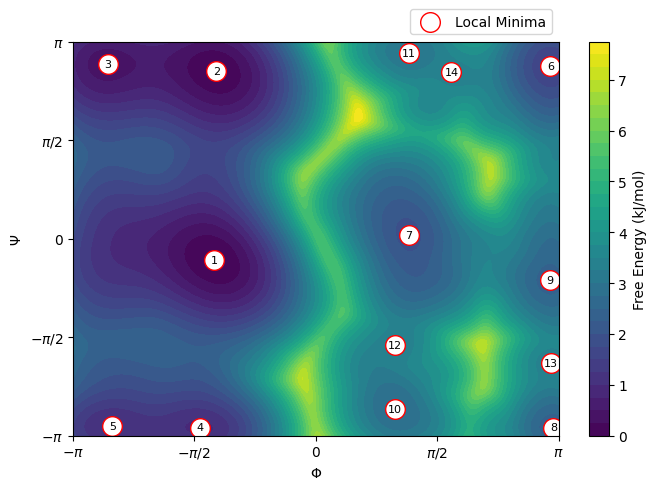

In [2]:

sigma = 0.2 # bandwidth for KDE
bin_x = 200
bin_y = 200
minima_tolerance = 0.15
n_BFGS_runs = 200
lag_time = 1


run_folder = \
    'ala2/solvated/300K/ala2_100ns'
    # 'ala2/solvated/200K/ala2_100ns'
    # 'ala2/solvated/273K/ala2_100ns'
    # 'ala2/solvated/283K/ala2_100ns'
    # 'ala2/solvated/293K/ala2_100ns'
    # 'ala2/solvated/303K/ala2_100ns'
    # 'ala2/solvated/313K/ala2_100ns'
    # 'ala2/solvated/323K/ala2_100ns'
    # 'ala2/solvated/333K/ala2_100ns'
    # 'ala2/solvated/343K/ala2_100ns'
    # 'ala2/solvated/353K/ala2_100ns'
    # 'ala2/solvated/363K/ala2_100ns'
    # 'ala2/solvated/373K/ala2_100ns'
phi, psi = calculate_dihedrals(run_folder)
# save_path = os.path.join(run_folder, '..','population_plot.png')
# population_plot(psi, phi, save_path, save_fig=True)
# save_path = os.path.join(run_folder, '..','rama_plot.png')
# rama_plot(psi, phi, save_path, save_fig=True)
kde, min_points = run_bfgs(phi, psi, 
                        sigma, bin_x, bin_y, 
                        minima_tolerance, n_BFGS_runs)
min_points = sort_minima_by_depth(kde, min_points)
Xgrid, Ygrid, fes = compute_fes(kde, bin_x, bin_y)
plot_fes(Xgrid, Ygrid, fes, min_points, save_path=None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Computing MFPT matrix: 100%|██████████| 6/6 [00:00<00:00, 16225.55it/s]


  Shape: (6, 6)
  Lag time: 1


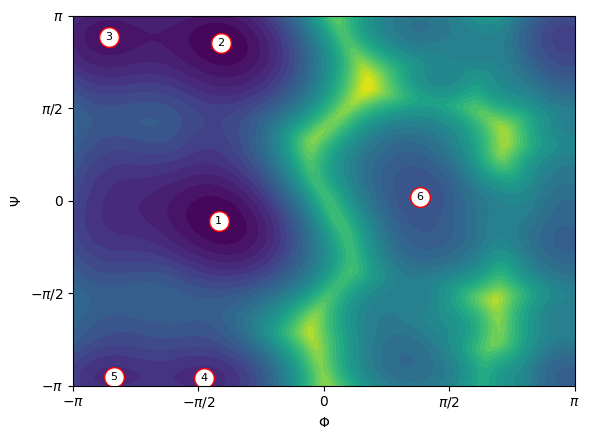

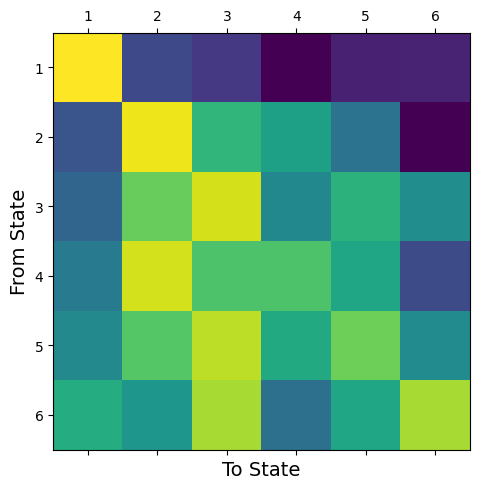

In [60]:
%load_ext autoreload
%autoreload 2
from data_generation.funcs import calculate_mfpt, plot_mfpt_matrix

selection_a = [1,2,3,4,5,7]#list(range(min(6, len(min_points))))
selection = [a-1 for a in selection_a] # convert to 0-based indexing
sel_points = min_points[selection]
save_path = os.path.join(run_folder, '..', 'plot_fes.png')
save_path = os.path.abspath(save_path)
plot_fes(Xgrid, Ygrid, fes, sel_points, save_path=save_path)
# states 
minima, transition_counts, transition_matrix, mfpt_matrix = calculate_mfpt(phi, psi, sel_points, lag_time=lag_time)
plot_mfpt_matrix(minima,
                    mfpt_matrix,
                    transition_counts,
                    transition_matrix,
                    save_path=os.path.join(run_folder,'..'),
                    lag_time=lag_time)
# with open(os.path.join(run_folder,'..', 'minima.txt'), 'w') as f:
#     for i, p in enumerate(min_points):
#         f.write(f"{p[0]:.4f}, {p[1]:.4f}\n")